# Preliminaries

In [ ]:
!pip install SimpleITK numpy matplotlib
!pip install --upgrade git+https://github.com/pyushkevich/upenn_be5370_utils.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.2 MB/s eta 0:00:00
  Cloning https://github.com/pyushkevich/upenn_be5370_utils.git to /tmp/pip-req-build-d2yqi3mg
  Running command git clone --filter=blob:none --quiet https://github.com/pyushkevich/upenn_be5370_utils.git /tmp/pip-req-build-d2yqi3mg
  Resolved https://github.com/pyushkevich/upenn_be5370_utils.git to commit 801c634d57f426a21c3a23762c332bdef43459a8
  Preparing metadata (setup.py) ... done
  Created wheel for upenn_be5370_utils: filename=upenn_be5370_utils-0.2-py3-none-any.whl size=11259 sha256=40d149ef7364089a7a9c3fb995d144c38f457450a0f91e202660775c9de35e34
  Stored in directory: /tmp/pip-ephem-wheel-cache-xsh_6owz/wheels/db/a8/d2/9e840877c2229dcd0d9c6e480b8829849c2ad13628794b0f75
Successfully built upenn_be5370_utils


In [ ]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import SimpleITK as sitk

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Registration')

# Import the functions from the first assignment
from upenn_be5370_utils.sitkview import view_sitk
from upenn_be5370_utils.transforms import *
# from phase_one_code import * # Commented out due to FileNotFoundError

# Configure matplotlib options
import matplotlib

# Root directory for the dataset
root = '/content/drive/MyDrive/Colab Notebooks/Registration/data'

# Fixed and moving images (change these to an arbitrary pair of subject ids)
id_fix, id_mov = 1015, 1009

In [ ]:
# Set up CUDA if available
force_cpu = False
if torch.cuda.is_available() and not force_cpu:
  cuda = torch.device('cuda', 0)
  print("Using CUDA device %d named '%s' with %6.2f Gb total memory" %
        (cuda.index, torch.cuda.get_device_name(cuda.index),
         torch.cuda.get_device_properties(cuda.index).total_memory / 2.0**30))
else:
  cuda = torch.device('cpu')
  print("Using CPU")

Using CUDA device 0 named 'Tesla T4' with  14.74 Gb total memory


## Applying deformations to images
The directory `testing` contains the output of a typical registration experiment, where the image `atlas_2mm_1000_3.nii.gz` was used as the fixed image, and `atlas_2mm_1001_3.nii.gz` was used as a moving image. First affine registration was performed, and then deformable registration. The affine transform is saved as `affine_fx_1000_mv_1001.mat`, and the warp as `warp_fx_1000_mv_1001.nii.gz`.

The code below loads the fixed and moving images. Then it loads the moving image to which affine and deformable registration was applied in Greedy. We will use these images to confirm that our calculations in Pytorch are working correctly.

In [ ]:
def my_sitk_to_torch(img, is_warp=False, **kwargs):
    """
    Convert 3D SimpleITK image to PyTorch 5D tensor. Supports scalar images
    and vector (multi-component) images.

    Args:
        img:
            SimpleITK image, 3D scalar or vector image
        is_warp:
            Boolean, indicates whether multi-component images should be treated as
            spatial transformations [1,D,H,W,3] or multi-channel images [1,C,D,H,W]
        dtype, device:
            These parameters will be passed on to torch.tensor()
    Output:
        A torch tensor holding the voxel data
    """
    # Convert SITK to numpy array
    arr = sitk.GetArrayFromImage(img)                       # pull voxel data out of the SITK image as a NumPy array
    arr = np.ascontiguousarray(arr)
    n_comp = int(img.GetNumberOfComponentsPerPixel())       # how many values per voxel (scalar if ==1, warp is everything else)

    # scalar image
    if n_comp == 1:

        # Scalar: [D,H,W] to [1,1,D,H,W]
        arr = arr[None, None, ...]                          # batch, channel
    else:                                                   # everything else
        if is_warp:
            # Warp: [D,H,W,3] to [1,D,H,W,3]
            if arr.shape[-1] != 3:
                raise ValueError("Warp images must have 3 components per voxel.")
            arr = arr[None, ...]
        else:
            # Multi-channel: [D,H,W,C] to [1,C,D,H,W]
            arr = np.moveaxis(arr, -1, 0)
            arr = arr[None, ...]

    return torch.tensor(arr, **kwargs)                      # NumPy array as a torch tensor


def my_torch_to_sitk(T, ref, is_warp=False):
    """
    Convert a PyTorch 5D tensor to a 3D SimpleITK image. Supports scalar images
    and vector (multi-component) images.

    Args:
        T:
            A 5-D tensor representing a scalar 3D image [1,1,D,H,W], a multi-channel
            3D image [1,C,D,H,W], or or a 3D spatial transformation [1,D,H,W,3]
        ref:
            Reference 3D image, a SimpleITK image from which the metadata including
            spacing, origin, and direction matrix will be assigned to the output image.
        is_warp:
            Boolean, indicates if the tensor represents a spatial transformation. If so,
            the tensor is expected to have shape [1,D,H,W,3].

    Output:
        A SimpleITK image.
    """
    # --- WRITE YOUR CODE HERE (~13 lines plus comments) ---

    t = T.detach().cpu()

    # Warp field: [1, D, H, W, 3] to [D, H, W, 3]
    if is_warp:
        arr = t[0].numpy()                                    # remove batch dimension and convert to NumPy
        arr = np.ascontiguousarray(arr)
        out = sitk.GetImageFromArray(arr, isVector=True)

    else:

        if t.shape[1] == 1:
            # Scalar: [1,1,D,H,W] to [D,H,W]
            arr = t[0, 0].numpy()
            arr = np.ascontiguousarray(arr)
            out = sitk.GetImageFromArray(arr, isVector=False)

        else:
            # Multi channel: [1,C,D,H,W] to [D,H,W,C]
            arr = t[0].permute(1, 2, 3, 0).numpy()
            arr = np.ascontiguousarray(arr)
            out = sitk.GetImageFromArray(arr, isVector=True)


    out.CopyInformation(ref)
    return out

# end of what I copied and pasted from phase 1

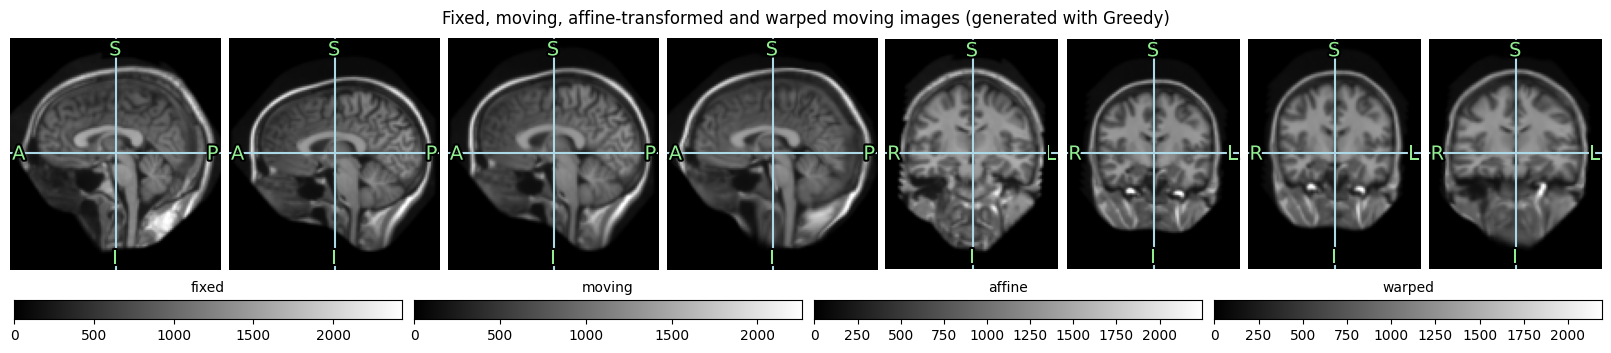

In [ ]:
# Load the fixed image
img_fix = sitk.ReadImage(f'{root}/testing/atlas_2mm_1000_3.nii.gz')

# Load the moving image
img_mov = sitk.ReadImage(f'{root}/testing/atlas_2mm_1001_3.nii.gz')

# Map to tensors
T_fix, T_mov = (my_sitk_to_torch(x, dtype=torch.float32) for x in (img_fix, img_mov))

# Load the result of applying the affine and deformable transformations to the moving image
# (this result was generated using Greedy and we load it to check our calculations)
img_affine_check = sitk.ReadImage(f'{root}/testing/reslice_affine_fx_1000_mv_1001.nii.gz')
img_warped_check = sitk.ReadImage(f'{root}/testing/reslice_deform_fx_1000_mv_1001.nii.gz')

# View the fixed and moving images side by side
view_sitk(img_fix, img_mov, img_affine_check, img_warped_check, layout='tttt', name=['fixed','moving','affine','warped'], width=16,
          title='Fixed, moving, affine-transformed and warped moving images (generated with Greedy)');

### Order of dimensions
3D images are represented in Pytorch as 5D-tensors of dimensions $[N,C,D,H,W]$ where $N$ is the mini-batch size (1 for now), $C$ is the number of channels (1 for grayscale, 3 for an RGB image), and $D, H, W$ are the dimensions of the 3D image.

Spatial transformations are 3D images that contain a coordinate $\phi({\boldsymbol x})$ at every voxel ${\boldsymbol x}$. They can be represented as 3D images with $C=3$ channels. The function `grid_sample` expects spatial transformations to be represented as 5D tensors with dimensions $[N,D,H,W,3]$. Instead of storing the spatial coordinates in the second dimension, the coordinates are stored in the last dimension. In this assignment, we will represent spatial transformations consistent with `grid_sample`.


### Spatial Transformation vs. Displacement Field
The distinction between a *spatial transformation* and a *displacement field.* A transformation $\phi$ assigns to each point $\boldsymbol{x}$ in the image domain another point, $\phi(\boldsymbol{x})$. A displacement field $\boldsymbol{u}$ assigns to each point $\boldsymbol{x}$ a displacement vector $\boldsymbol{u}(\boldsymbol{x})$. The two are related simply as $\phi(\boldsymbol{x})=\boldsymbol{x}+\boldsymbol{u}(\boldsymbol{x})$. Because of this simple relationship, we can think of a displacement field as just another way to represent a spatial transformation. It turns out that in practice representing spatial transformations as displacement fields is easier, particularly when it comes to applying composition operations to spatial transformations. In this assignment, we will represent spatial transformations as displacement fields.

The next code snippet loads a displacement field (or "warp") computed using [Greedy](https://github.com/pyushkevich/greedy) between the fixed and moving images and applies it to the moving image. The transformed (or "resliced") moving image is displayed as an overlay on top of the fixed image. Observe that the contours from the resliced moving image match the structures in the fixed image better than in the previous plot.

### Utilities for Working With Deformation Fields

In [ ]:
def my_create_pytorch_grid(img_tensor_dim, **kwargs):
    """
    Generate an identity grid for use with grid_sample, similar to meshgrid in NumPy

    :param img_tensor_dim: Dimensions of tensor holding the reference image (tuple of 5 values)
    :param dtype: PyTorch data type for the grid (see torch.Tensor)
    :param device: PyTorch device for the grid (see torch.Tensor)
    :returns: 5D tensor of dimension [1,S_x,S_y,S_z,3] containing the grid
    """

    # Generate a 3x4 representation of and identity matrix
    T_idmat = torch.eye(3,4).unsqueeze(0)

    # Update the type and device of the grid
    T_dummy = torch.zeros(1, **kwargs)

    # Generate a sampling grid inside of a no_grad block
    T_grid = F.affine_grid(T_idmat, img_tensor_dim, align_corners=False).to(**kwargs)

    return T_grid

This helper function is used to load displacement fields saved by registration tools like [ANTs](http://stnava.github.io/ANTs/) and [Greedy](https://github.com/pyushkevich/greedy)

In [ ]:
def map_warp_sitk_to_pytorch(img_warp):
    """
    Transform a SimpleITK displacement field in Greedy/ANTs format to the
    corresponding displacement field that can be used with PyTorch `grid_sample`
    command.
    """

    # This is the PyTorch coordinate transform
    S_pt = 2.0 / np.array(img_warp.GetSize())
    D_pt = np.eye(3)
    DS_pt = D_pt @ np.diag(S_pt)

    # This is the image direction matrix
    D_itk = np.array(img_warp.GetDirection()).reshape(3,3)
    S_itk = np.array(img_warp.GetSpacing())
    DS_itk_inv = np.linalg.inv(D_itk @ np.diag(S_itk))

    # Affine matrix that should be applied to the displacements
    A = DS_pt @ DS_itk_inv

    # Apply this to the displacements
    x_itk = sitk.GetArrayFromImage(img_warp)
    x_pt = np.einsum('ij,xyzj->xyzi', A, x_itk)

    # Create a new image
    img_warp_pt = sitk.GetImageFromArray(x_pt, isVector=True)
    img_warp_pt.SetSpacing(S_pt.tolist())
    img_warp_pt.SetDirection(D_pt.flatten().tolist())
    img_warp_pt.SetOrigin([-1, -1, -1])

    return img_warp_pt

**Task 1 : A function that can apply a combination of an affine and deformable transformation to the moving image.** T

$$
J'_\mathrm{affine}(\mathbf{x}) = J(\mathbf{A}\mathbf{x}+\mathbf{b})
$$

$$
J'_\mathrm{deform}(\mathbf{x}) = J'_\mathrm{affine}(\phi(\mathbf{x}))
$$


In [ ]:
def my_transform_image_pytorch(T_grid, T_mov, A=None, b=None, T_warp=None,
                               mode='bilinear', padding_mode='zeros'):
    if T_warp is not None:
        T_grid = T_grid + T_warp                      # 1) add deformable warp
    A = A.to(device=T_grid.device, dtype=T_grid.dtype)
    b = b.to(device=T_grid.device, dtype=T_grid.dtype)
    T_grid = torch.einsum("ij,...j->...i", A, T_grid) + b   # 2) apply affine
    J_out = F.grid_sample(T_mov, T_grid,                   # 3) sample moving image
                          mode=mode, padding_mode=padding_mode,
                          align_corners=False)                  # 4) required by assignment
    return J_out

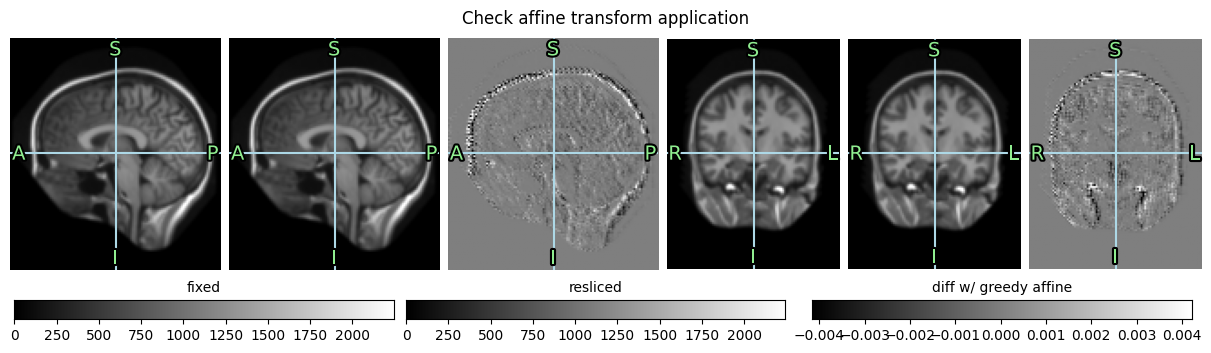

In [ ]:
# Load the affine transform into an sitk object (replace the filename with yours)
tran_itk = load_itksnap_transform(f'{root}/testing/affine_fx_1000_mv_1001.mat')

# Convert to the format compatible with affine_grid
A, b = map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov)
T_A, T_b = (torch.tensor(x, dtype=torch.float32) for x in (A,b))

# Apply only the affine transformation
T_grid = my_create_pytorch_grid(T_fix.shape, dtype=T_fix.dtype)
T_res_aff = my_transform_image_pytorch(T_grid, T_mov, T_A, T_b)

# Compare the three sets of images. The difference image should have range (-0.005, 0.005), compared to (0, 2000) for the input fixed and moving images
view_sitk(img_affine_check, my_torch_to_sitk(T_res_aff, img_fix), my_torch_to_sitk(T_res_aff, img_fix)-img_affine_check, layout='ttt',
          width=12, name=['fixed','resliced','diff w/ greedy affine'], title='Check affine transform application');

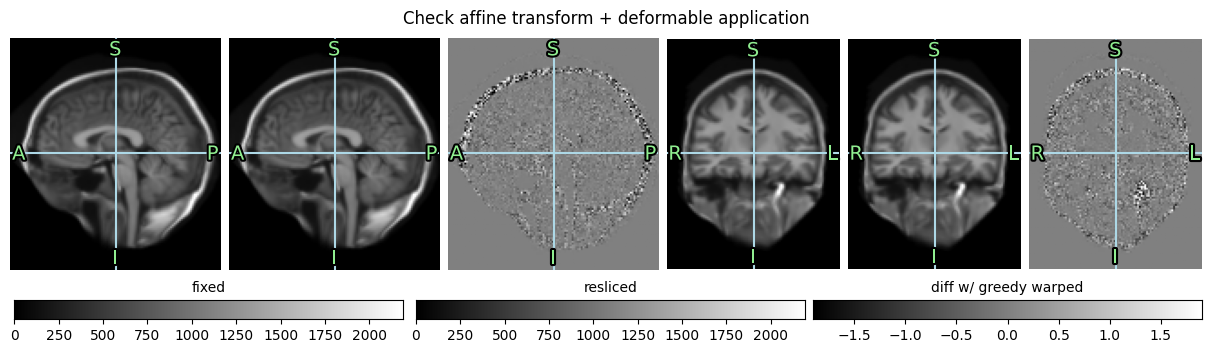

In [ ]:
# Load a transformation from file
img_warp = sitk.ReadImage(f'{root}/testing/warp_fx_1000_mv_1001.nii.gz')
img_warp_pt = map_warp_sitk_to_pytorch(img_warp)
T_warp = my_sitk_to_torch(img_warp_pt, is_warp=True, dtype=T_fix.dtype)

# Here your function is being called with warp as an input
T_res_warped = my_transform_image_pytorch(T_grid, T_mov, T_A, T_b, T_warp)

# Compare the three sets of images. The difference image should have range (-2, 2), compared to (0, 2000) for the input fixed and moving images
view_sitk(img_warped_check, my_torch_to_sitk(T_res_warped, img_fix), my_torch_to_sitk(T_res_warped, img_fix)-img_warped_check, layout='ttt',
          width=12, name=['fixed','resliced','diff w/ greedy warped'], title='Check affine transform + deformable application');

# Implement Diffeomorphic Demons Registration in PyTorch

## Building blocks of the algorithm
Implementing the *Log-Domain Demons* algorithm by Vercauteren et al. (2008) will require the following components:

- **Scaling and squaring**, a technique that converts a smooth and bounded velocity field into a diffeomorphic transformation

- **Image gradient computation**, needed to compute optical flow between fixed and moving images

- **Gaussian smoothing**, used to regularize velocity fields and displacement fields

- **Optical flow computation**,

## Scaling and squaring
Scaling and squaring takes as input a vector field called a **stationary velocity field (SVF)** and generates a spatial transformation that is diffeomorphic.

### Theory: Scaling and Squaring using Displacement Fields

Since we will be working with displacement fields, we need to rewrite the algorithm in terms of displacement fields.


-   If $\psi_1$ and $\psi_2$ are transformations with corresponding displacement fields $\boldsymbol{v}_1$ and $\boldsymbol{v}_2$, then the displacement field $\boldsymbol{w}$ corresponding to the transformation $\psi_1\circ\psi_2$ (the composition of $\psi_1$ and $\psi_2$) is given by $$\boldsymbol{w}(\boldsymbol{x})=\boldsymbol{v}_2(\boldsymbol{x})+\boldsymbol{v}_1(\boldsymbol{x}+\boldsymbol{v}_2(\boldsymbol{x}))$$

**TASK 2a Proof

Given two spatial transformations:

$$
\psi_1(x) = x + v_1(x)
$$

$$
\psi_2(x) = x + v_2(x)
$$

The composition is:

$$
(\psi_1 \circ \psi_2)(x) = \psi_1(\psi_2(x))
$$

Substitute the definition of $\psi_2$:

$$
(\psi_1 \circ \psi_2)(x) = \psi_1(x + v_2(x))
$$

Now substitute $\psi_1$:

$$
\psi_1(x + v_2(x)) = (x + v_2(x)) + v_1(x + v_2(x))
$$

Simplify:

$$
(\psi_1 \circ \psi_2)(x) = x + v_2(x) + v_1(x + v_2(x))
$$

A displacement field $w(x)$ satisfies:

$$
(\psi_1 \circ \psi_2)(x) = x + w(x)
$$

Thus:

$$
w(x) = v_2(x) + v_1(x + v_2(x))
$$


**TASK 2b : Algorithm **


**Scaling step:**

$$
v_0(x) = \frac{1}{2^N} v(x)
$$

**Squaring step:**  
For $k = 1, 2, \ldots, N$:

$$
v_k(x) = v_{k-1}(x) + v_{k-1}(x + v_{k-1}(x))
$$

(using the displacement-field composition rule from Task 2a)


```
Input: stationary velocity field v(x), number of squaring steps N

1. Scaling:
      v0(x) = v(x) / (2^N)

2. Squaring:
      for k = 1 to N:
          vk(x) = vk-1(x) + vk-1( x + vk-1(x) )

3. Output:
      displacement φ(x) = x + vN(x)
```

### Implementation of Scaling and Squaring

In [ ]:
def my_scaling_and_squaring(u, grid, n = 6):
    """
    Apply scaling and squaring to a displacement field

    The input and output to this method are displacement fields, v and u,
    respectively. If u is sufficiently smooth and bounded, theoretically,
    the deformation field $\\phi(x) = x + u(x)$ will be diffeomorphic

    :param u: Input stationary velocity field, PyTorch tensor of shape [1,D,H,W,3]
    :param grid: Sampling grid of size [1,D,H,W,3] (created by my_create_pytorch_grid)
    :param n: Number of iterations of scaling and squaring (default: 6)

    :returns: Output displacement field, v, PyTorch tensor of shape [1,D,H,W,3]
    """
    #scale the velocity field for stability
    v = u / (2.0 ** n)
    #squaring loop
    for i in range(n):
        #compute displaced positions: grid + v (still [1,D,H,W,3])
        disp_grid = grid + v
        v_perm = v.permute(0, 4, 1, 2, 3)# Permute for grid_sample: [1,3,D,H,W]
        #use grid_sample: input must be [N,C,D,H,W], grid must be [N,D,H,W,3]
        sampled = F.grid_sample(v_perm,disp_grid,align_corners=False,mode='bilinear',padding_mode='border').permute(0, 2, 3, 4, 1)  # Back to [1,D,H,W,3]
        # Final composition step: v(x) + v(x + v(x))
        v = v + sampled
    return v

### Test Scaling and Squaring

To confirm that the code is working correctly, we perform the following test:

1. Load a sample stationary velocity field `I_svf` from `testing/svf_fx_1000_mv_1001.nii.gz`
2. Apply scaling and squaring to `I_svf` and use the result to transform the moving image
3. Compare the result to the moving image transformed using `I_warp` above

Difference between T_res_warped_ss and T_res_warped
  Mean absolute difference:  0.10846802592277527
  Maximum absolute difference:  4.75225830078125


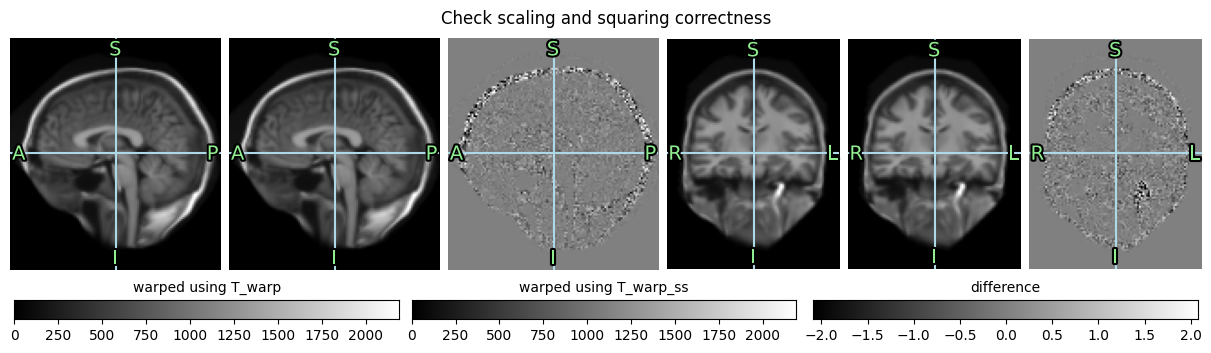

In [ ]:
# Load the root warp (stationary velocity field)
img_svf = sitk.ReadImage(f'{root}/testing/svf_fx_1000_mv_1001.nii.gz')
img_svf_pt = map_warp_sitk_to_pytorch(img_svf)
T_svf = my_sitk_to_torch(img_svf_pt, is_warp=True, dtype=T_fix.dtype)

# Apply scaling and squaring to the SVF (for 6 iterations)
T_warp_ss = my_scaling_and_squaring(T_svf, T_grid, 6)

# Sample the moving image using this transformation
T_res_warped_ss = my_transform_image_pytorch(T_grid, T_mov, T_A, T_b, T_warp_ss)

# Compare the result to the moving image sampled using the warp generated by Greedy
print('Difference between T_res_warped_ss and T_res_warped')
print('  Mean absolute difference: ' , torch.mean(torch.abs(T_res_warped_ss-T_res_warped)).item())
print('  Maximum absolute difference: ', torch.max(torch.abs(T_res_warped_ss - T_res_warped)).item())

# Generate a comparison view
view_sitk(my_torch_to_sitk(T_res_warped, img_fix),
          my_torch_to_sitk(T_res_warped_ss, img_fix),
          my_torch_to_sitk(T_res_warped_ss, img_fix)-my_torch_to_sitk(T_res_warped, img_fix),
          layout='ttt', width=12, name=['warped using T_warp','warped using T_warp_ss','difference'], title='Check scaling and squaring correctness');

## Gradient computation

We will need to approximate the gradient of the moving image during each step of the deformable registration algorithm. The gradient of an image can be represented as a multi-component image $\nabla I (\boldsymbol{x}) : \mathbb{R}^3 \rightarrow \mathbb{R}^3$. At each voxel, this image contains the three partial derivatives of $I$ with respect to the coordinates $x_1$, $x_2$, $x_3$:

$$ \nabla I (\boldsymbol{x}) = \left[ \frac{\partial I}{\partial x_1}, \frac{\partial I}{\partial x_2}, \frac{\partial I}{\partial x_3} \right]^T $$

It turns out that the images $\frac{\partial I}{\partial x_1}$, $\frac{\partial I}{\partial x_2}$, and $\frac{\partial I}{\partial x_3}$ can each be approximated as discrete convolutions of the image $I$ with simple kernels consisting of three elements.

### Theory: Derive Central Difference Approximation

For a discrete 3D image $I$ with inter-voxel spacing $\delta_1,\delta_2,\delta_3$, the partial derivative $\frac{\partial I}{\partial x_k}$ at a voxel $\boldsymbol{x}$ can be approximated using the values of $I$ at the six adjacent voxels $I(\boldsymbol{x} + \delta_1 \boldsymbol{e}_1)$, $I(\boldsymbol{x} - \delta_1 \boldsymbol{e}_1)$, $I(\boldsymbol{x} + \delta_2 \boldsymbol{e}_2)$, $I(\boldsymbol{x} - \delta_2 \boldsymbol{e}_2)$, $I(\boldsymbol{x} + \delta_3 \boldsymbol{e}_3)$, $I(\boldsymbol{x} - \delta_3 \boldsymbol{e}_3)$. Here $\boldsymbol{e}_k$ denotes the unit vector along spatial dimension $k$, i.e., $\boldsymbol{e}_1 = [1,0,0]^T$, etc. This is known as the *central difference approximation* of the derivative.

Taylor series allows us to approximate the value of the function $I$ at some position $\boldsymbol{y}$  in terms of the value of $I$ and its first and second partial derivatives at another position $\boldsymbol{x}$:

$$ I(\boldsymbol{y}) \simeq I(\boldsymbol{x}) + \sum_{i=1}^{3} \frac{\partial I}{\partial x_i}(\boldsymbol{x}) \cdot (y_i - x_i)
 + \sum_{i=1}^{3}\sum_{j=1}^{3} \frac{\partial^2 I}{\partial x_i \partial x_j}(\boldsymbol{x}) \cdot \frac{(y_i - x_i)(y_j - x_j)}{2}\,. $$

Taylor series approximations for the intensity at $I(\boldsymbol{x} + \delta_1 \boldsymbol{e}_1)$ and $I(\boldsymbol{x} - \delta_1 \boldsymbol{e}_1)$ involve the unknown quantity $\frac{\partial I}{\partial x_1}(\boldsymbol{x})$. 

### Implementation

In [ ]:
# Compute the gradient of a 3D image in PyTorch
def my_image_gradient(I):
    """
    Compute the gradient of an image using central difference approximation

    :param I: input image, represented as a [N,1,D,H,W] tensor
    :returns: gradient of the input image, represented as a [N,3,D,H,W] tensor
    """

    N, C, D, H, W = I.shape # batch size, n channels, depth, height, width

    # N1 = D, N2 = H, N3 = W, 3D grid spans from −1 to +1
    delta1 = 2.0 / (D)  # spacing along x1, depth
    delta2 = 2.0 / (H)  # spacing along x2, height
    delta3 = 2.0 / (W)  # spacing along x3, width

    device = I.device # kernels on GPU
    dtype = I.dtype

    # kernels: out_channels, in_channels, depth, height, width]
    kernels = torch.zeros((3, 1, 3, 3, 3), device=device, dtype=dtype)

    # Central difference 1 / (2 * delta) * [-1, 0, 1]
    stencil = torch.tensor([-1.0, 0.0, 1.0], device=device, dtype=dtype) # inserted along each axis

    # dI/dx1: depth
    kernels[0, 0, 1, 1, :] = stencil / (2.0 * delta1)

    # dI/dx2: height
    kernels[1, 0, 1, :, 1] = stencil / (2.0 * delta2)

    # dI/dx3: width
    kernels[2, 0, :, 1, 1] = stencil / (2.0 * delta3)

    # apply convolution, get output [N, 3, D, H, W] tensor
    grad = F.conv3d(I, kernels, padding=1)

    return grad

### Check Gradient Computation

Here we plot the image gradient components and gradient magnitude image, i.e., an image where at every voxel the intensity is equal to $|\nabla I|$. The gradient magnitude is large at edges in the image.


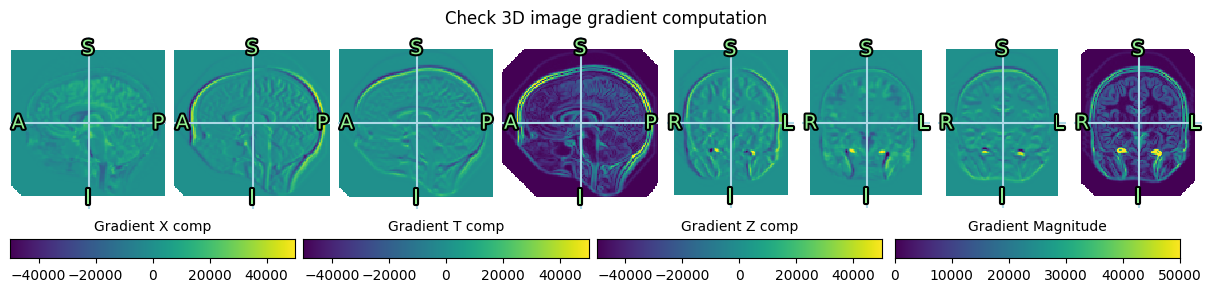

In [ ]:
T_mov_grad = my_image_gradient(T_mov)
T_mov_grad_mag = (T_mov_grad**2).sum(dim=1, keepdim=True)**0.5
view_sitk(
    my_torch_to_sitk(T_mov_grad[:,0:1,:,:,:], img_fix),
    my_torch_to_sitk(T_mov_grad[:,1:2,:,:,:], img_fix),
    my_torch_to_sitk(T_mov_grad[:,2:,:,:,:], img_fix),
    my_torch_to_sitk(T_mov_grad_mag, img_fix),
    layout='ttt', width=12, name=['Gradient X comp','Gradient T comp','Gradient Z comp','Gradient Magnitude'], title='Check 3D image gradient computation', cmap='viridis',
    vmin=[-50000,-50000,-50000,0], vmax=50000);

## Gaussian Smoothing
Implementing Gaussian smoothing in Pytorch efficiently requires computing the fast Fourier transform (FFT) of the input image and the Gaussian kernel, multiplication in the frequency domain, and taking the inverse FFT.

In [ ]:
# Function to generate a 3D Gaussian kernel in Numpy
def my_gaussian_3d(sigma):
    t_range = np.arange(-np.ceil(3.5*sigma), np.ceil(3.5*sigma)+1)
    gaussian_1d = np.exp(- t_range**2 / (2*sigma**2)) / (np.sqrt(2*np.pi)*sigma)
    return np.tensordot(np.tensordot(gaussian_1d, gaussian_1d, axes=0),
                        gaussian_1d, axes=0)

# Function to generate FFT of a Gaussian kernel for use in PyTorch FFT
def my_gaussian_fft_kernel(I_ref, sigma):
    """
    Generate the FFT of a Gaussian kernel that can be used for FFT-based Gaussian smoothing

    :param I_ref: 5D tensor that will be convolved with the kernel, used to infer the
                  shape, data type and device for the output kernel
    :param sigma: standard deviation of the Gaussian kernel
    :param dtype: data type of the output tensor (default: torch.float32)
    :returns: 5D tensor that can be multiplied by the image RFFT for FFT-based smoothing
    """

    # Generate a Gaussian kernel, convert to PyTorch
    K = torch.tensor(my_gaussian_3d(sigma),
                     dtype=I_ref.dtype, device=I_ref.device).unsqueeze(0).unsqueeze(0)

    # Normalize the kernel
    K = K / K.sum()

    # Pad the kernel so it is centered in an image of size I_ref.shape
    ab_pad = np.array(I_ref.shape[2:5]) - np.array(K.shape[2:5])
    a_pad = np.floor(ab_pad / 2)
    b_pad = ab_pad - a_pad
    pad_5d = tuple(np.flip(np.vstack((a_pad, b_pad)).T.flatten()).astype(int))+(0,0,0,0)
    K_pad = F.pad(K,pad_5d)

    # Return the real FFT of the kernel
    return torch.fft.rfftn(K_pad)


# Function to smooth a scalar image with a Gaussian using PyTorch FFT
def my_pytorch_gaussian_lpf(img, sigma=None, kernel=None):
    """
    Apply Gaussian smoothing to a 3D image represented as a PyTorch tensor

    You can pass in the sigma of the Gaussian or a 5D tensor representing the Gaussian
    kernel (generated using `my_gaussian_fft_kernel`). The latter is faster if you will
    be making repeated calls to this function.

    :param img: Input image, represented as a 5D tensor
    :param sigma: Standard deviation of the Gaussian kernel. If `kernel` parameter
        is not supplied, the kernel will be generated by calling `my_gaussian_fft_kernel`
    :param kernel: Gaussian kernel generated by `my_gaussian_fft_kernel`.
    """

    # Either sigma or kernel must be provided
    assert sigma is not None or kernel is not None
    if kernel is None:
        kernel = my_gaussian_fft_kernel(img, sigma)

    # Create a Gaussian kernel
    img_fft = torch.fft.rfftn(img)
    return torch.fft.fftshift(torch.fft.irfftn(img_fft * kernel))


# Function to smooth a deformation field with a Gaussian
def my_pytorch_gaussian_lpf_transform(v, sigma=None, kernel=None):
    """
    Apply Gaussian smoothing to a transform represented as a PyTorch tensor

    You can pass in the sigma of the Gaussian or a 5D tensor representing the Gaussian
    kernel (generated using `my_gaussian_fft_kernel`). The latter is faster if you will
    be making repeated calls to this function.

    :param img: Input spatial transformation, represented as a [N,D,H,W,3] tensor
    :param sigma: Standard deviation of the Gaussian kernel. If `kernel` parameter
        is not supplied, the kernel will be generated by calling `my_gaussian_fft_kernel`
    :param kernel: Gaussian kernel generated by `my_gaussian_fft_kernel`.
    """

    # Make sure the image is formatted as a transform
    assert v.shape[4]==3

    # Convert the transform into a multi-channel image of shape [1,3,D,H,W]
    v_chan = v.permute(0,4,1,2,3)

    # Either sigma or kernel must be provided
    assert sigma is not None or kernel is not None
    if kernel is None:
        kernel = my_gaussian_fft_kernel(v_chan, sigma)

    # Perform FFT convolution but only along image dimensions
    v_fft = torch.fft.rfftn(v_chan, dim=(-3,-2,-1))
    v_sm_chan = torch.fft.fftshift(
        torch.fft.irfftn(v_fft * kernel, dim=(-3,-2,-1)),
        dim=(-3,-2,-1))

    # Reorder dimensions again
    return v_sm_chan.permute(0,2,3,4,1)

Here is an example of the fixed image smoothed in Pytorch

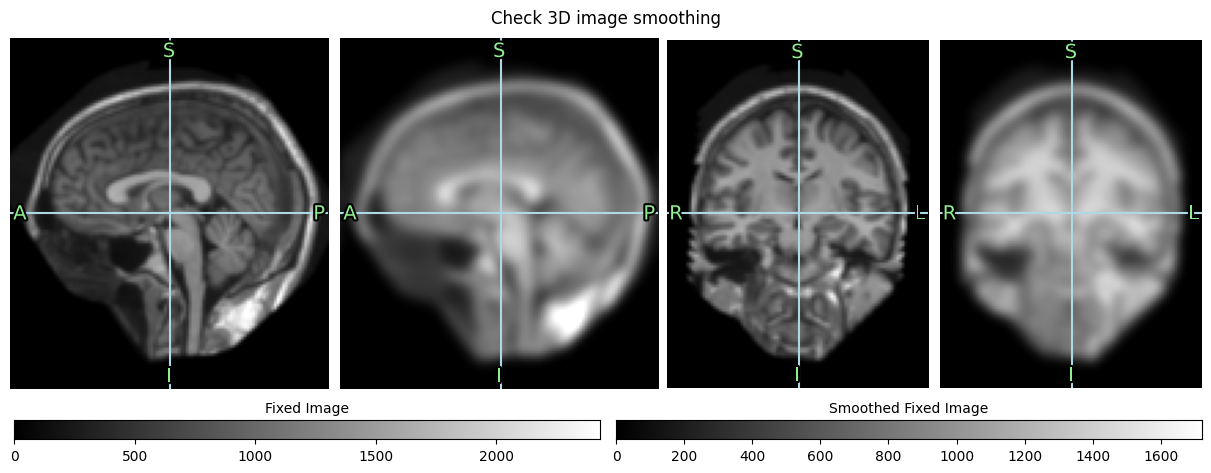

In [ ]:
T_fix_sm = my_pytorch_gaussian_lpf(T_fix, sigma=2.0)
view_sitk(
    my_torch_to_sitk(T_fix, img_fix),
    my_torch_to_sitk(T_fix_sm, img_fix),
    layout='tt', width=12, name=['Fixed Image', 'Smoothed Fixed Image'], title='Check 3D image smoothing', cmap='gray');

And here, more importantly, is an example of a deformation field smoothed in PyTorch

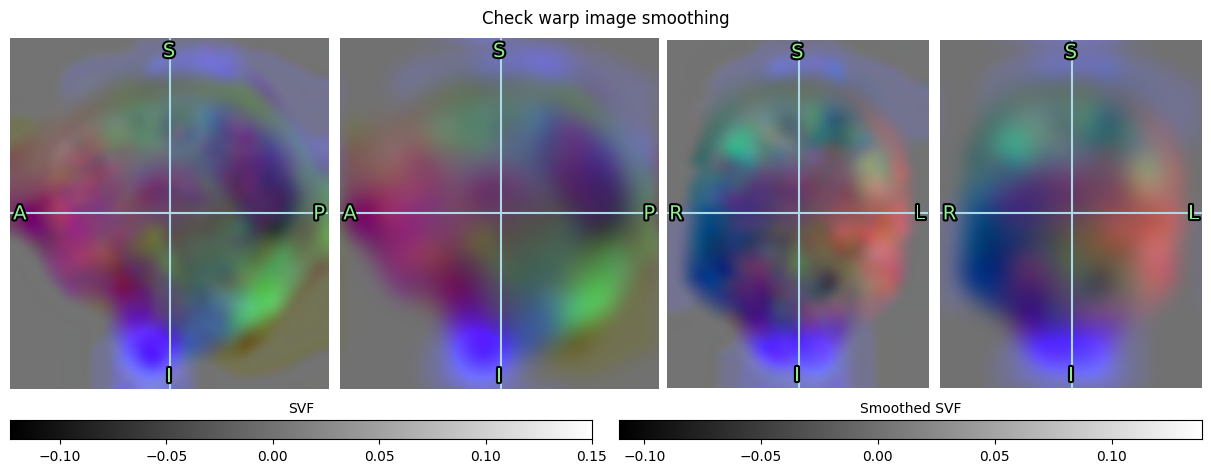

In [ ]:
T_svf_sm = my_pytorch_gaussian_lpf_transform(T_svf, sigma=3.0)

view_sitk(
    my_torch_to_sitk(T_svf.permute(0,4,1,2,3), img_fix),
    my_torch_to_sitk(T_svf_sm.permute(0,4,1,2,3), img_fix),
    layout='tt', width=12, name=['SVF','Smoothed SVF'], title='Check warp image smoothing');

## Optical flow computation

Optical flow infers a velocity field from a pair of images. When these images are frames from a video sequence, the optical flow is an estimate of how fast objects or particles are moving in the video. When doing inter-subject registration, optical flow does not have the same clear physical meaning, but it can be thought of as an infinitecimal displacement that, when applied to the moving image, makes it a little more similar to the fixed image.

### Optical Flow Algorithms

**two versions** of the optical flow approximation.

One of them will be a simple approximation that is obtained if we differentiate the mean square difference metric  (MSD, also known as the sum of squared differences metric, or SSD) between $I(\boldsymbol{x})$ and $J^i(\boldsymbol{x}+\boldsymbol{v}(\boldsymbol{x}))$ with respect to $\boldsymbol{v}$. This approximation is referred to as `grad_msd` in the code below.

$${\boldsymbol{v}} = G_\sigma * (I - J^i) \nabla J^i $$

The other one can be one of the following:
* The original *Demons* approximation
* The Lukas-Kanade algorithm 
* The Horn and Schunk algorithm 

### Implementation as a Python Class

A class is an object-oriented programming concept that allows data and functions to be abstracted away into a single entity. We will write a Python class to capture the logic of optical flow computation. The class will have a constructor (`__init__` function) that users call to configure the class (e.g., specify which optical flow method to use or how much smoothing to perform) and a method called `forward` that will perform the actual computation. Once we create an instance of this class, we can call `forward` multiple times with different image inputs.

In [ ]:
class MyOpticalFlow:

    """A class that implements multiple optical flow algorithms"""
    def __init__(self, I, method='demons', sigma=2.0, demons_eps=0.001):
        """
        Initialize the optical flow computation

        :param I: Fixed image, represented as [N,1,D,H,W] tensor
        :param method:
            String, specifies which method is used for the computation. Available
            options are 'demons' (default) and 'grad_msd'
        :param sigma:
            Standard deviation for Gaussian smoothing in 'demons' and 'grad_msd'
            methods (passed to `my_gaussian_fft_kernel`)
        :param demons_eps:
            Only used if `method=='demons'`, sets the threshold on the denominator
            below which the flow is set to zero. See Algorithm 2 step 2b
        """
        self.method = method
        self.demons_eps = demons_eps
        # Store sigma directly, as my_pytorch_gaussian_lpf_transform will generate its own kernel
        self.kernel_sigma = my_gaussian_fft_kernel(I, sigma)

    def forward(self, I, J):
        """
        Compute optical flow for a given pair of fixed/moving images

        :param I: fixed image, represented as [N,1,D,H,W] tensor
        :param J: moving image, represented as [N,1,D,H,W] tensor
        :returns: optical flow velocity field, represented as a [N,D,H,W,3] tensor
        """

        # Difference moving - fixed
        diffI = I - J       # IMPORTANT! Correct sign
        diffJ = J - I
        # ∇I: [N,3,D,H,W]
        gradI = my_image_gradient(I)
        gradJ = my_image_gradient(J)
        if self.method == 'demons':
            # numerator = (J - I) ∇I
            numer = diffJ * gradI

            # denom = ∇I^2 + (J - I)^2
            denom = torch.square(diffJ) + torch.sum(torch.square(gradI), dim=1, keepdim=True)
            v = torch.where(denom > self.demons_eps, numer / denom, torch.zeros_like(gradI))
            v = my_pytorch_gaussian_lpf_transform(v.permute(0,2,3,4,1), kernel=self.kernel_sigma)

        elif self.method == 'grad_msd':
            #grad_diff = my_image_gradient(diff)
            numer = diffI * gradJ
            v = my_pytorch_gaussian_lpf_transform(numer.permute(0,2,3,4,1), kernel=self.kernel_sigma)

        else:
            raise ValueError("Unknown optical flow method.")

        return v

### Check Optical Flow Computation

![Optical flow visualization](files/oflow_example.png)

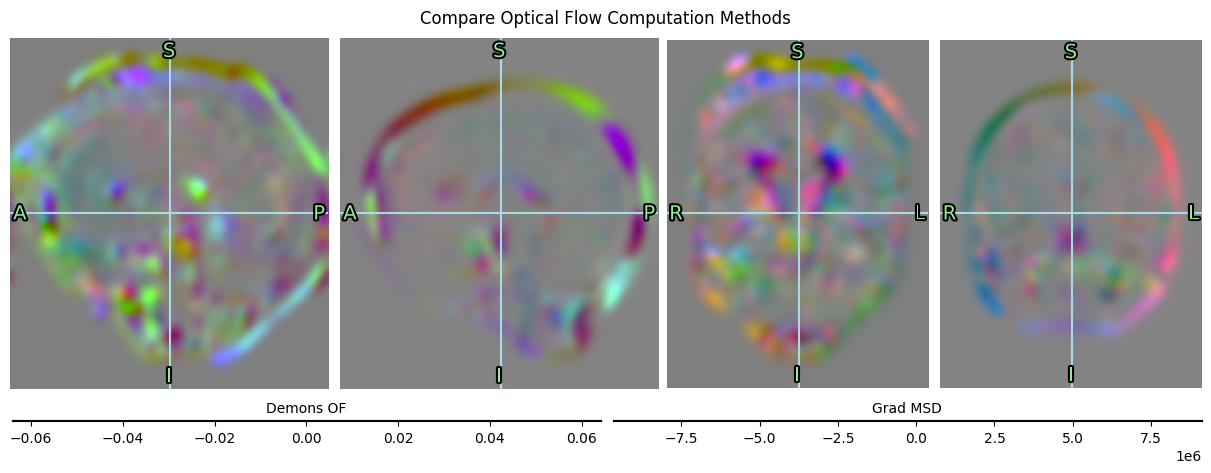

In [ ]:
import matplotlib.ticker as ticker

of_demons = MyOpticalFlow(T_fix, method='demons', sigma=2.0)
v_demons = of_demons.forward(T_fix, T_res_aff)

of_gradmsd = MyOpticalFlow(T_fix, method='grad_msd', sigma=2.0)
v_gradmsd = of_gradmsd.forward(T_fix, T_res_aff)

view_sitk(
    my_torch_to_sitk(v_demons.permute(0,4,1,2,3), img_fix),
    my_torch_to_sitk(v_gradmsd.permute(0,4,1,2,3), img_fix),
    layout='tt', width=12, name=['Demons OF','Grad MSD'], title='Compare Optical Flow Computation Methods');

## Log-Demons Algorithm

### Full-Resolution Method
We can implement the log-Demons algorithm,  as a Python class `MyLogDemonsAlgorithm`

The method `__init__` will be responsible for storing the variables needed by the class (i.e., lines of code line `self.I = I`) and initializing the sampling grid and other objects that are repeatedly used during the algorithm.

The method `step` is the portion of the algorithm that is iterated. At every call to `step`, the spatial transformation $\phi^i$ and the stationary velocity field $u^i$ are updated. Note that consisently with how we implemented scaling and squaring, we use the displacement field $\boldsymbol{w}^i$ to represent the spatial transformation $\phi^i$ in our code. The two are related by $\phi^i(\boldsymbol{x}) = \boldsymbol{x} + \boldsymbol{w}^i(\boldsymbol{x})$.


In [ ]:
class MyLogDemonsAlgorithm:
    """A class that performs log-Demons registration between two images"""

    def __init__(self, I, J, of, tau=0.5, eps_prime = 0.5):
        """
        Initialize the Log Demons algorithm

        :param I: Fixed image, represented as an [N,1,D,H,W] tensor
        :param J: Moving image, represented as an [N,1,D,H,W] tensor
        :param of:
            Instance of class MyOpticalFlow used to perform optical flow computations
        :param tau:
            Standard deviation for 'diffusion-like' regularization (Algorithm 4, Line 2c)
        :param eps_prime:
            Normalization factor. The velocity field computed by optical flow will
            be scaled so that the longest velocity vector is equal to eps_prime
            voxel widths. See second bullet point after Algorithm 3.
        """
        self.I = I
        self.J = J
        self.of = of
        self.kernel_tau = my_gaussian_fft_kernel(I, tau)
        self.eps_prime = eps_prime
        self.grid = my_create_pytorch_grid(I.shape, dtype=I.dtype, device=I.device)

    def step(self, w_i, u_i):
        """
        Execute one iteration of the Log Demons algorithm (Algorithm 4, Line 2)

        :param w_i:
            Displacement field corresponding to the current estimate of the spatial
            transformation. Transformation $\\phi_i$ is given by $\\phi_i(x) = x + w_i(x)$.
            Represented as an [N,1,D,H,W] tensor.
        :param u_i:
            Current estimate of the stationary velocity field $u_i$
            Represented as an [N,1,D,H,W] tensor.

        :returns:
            Tuple (Ji, rms, w_i1, u_i1) where

            - `Ji` is the moving image transformed by the spatial transformation $\\phi_i$
            - `msd` is the mean square intensity difference between I and J^i
            - `w_i1` is the updated displacement field corresponding to $\\phi_{i+1}$
            - `u_i1` is the updated stationary velocity field
        """

        # Resample the moving image using current displacement field w_i
        J_i = F.grid_sample(self.J, self.grid + w_i, align_corners=False)

        # Compute the RMS metric between fixed image I and resampled moving image
        msd = torch.mean((self.I - J_i).square())

        # Compute the optical flow field between fixed image I and resampled moving image
        v_i = self.of.forward(self.I, J_i)

        # Scale the optical flow field so the longest vector does not exceed eps_prime
        # (eps_prime is specified in voxel units, e.g., 0.5 voxel).
        scale = self.eps_prime * np.min(2.0 / np.array(self.I.shape[2:5])) / torch.max(v_i).item()

        # Compute the updated SVF using the approximation of the Lie bracket term in Algorithm 4 line 2c
        u_i1 = my_pytorch_gaussian_lpf_transform(u_i + scale * v_i, kernel=self.kernel_tau)

        # Perform scaling and squaring to get a new transformation
        w_i1 = my_scaling_and_squaring(u_i1, self.grid)

        # Return the updated w and u
        return J_i, msd, w_i1, u_i1

In [ ]:
log_demons = MyLogDemonsAlgorithm(T_fix, T_res_aff, of_gradmsd)
w_i = torch.zeros_like(T_fix).repeat((1,3,1,1,1)).permute(0,2,3,4,1)
u_i = w_i.clone()
for k in range(201):
    J_i, msd, w_i, u_i = log_demons.step(w_i, u_i)
    if k % 20 == 0:
        print('Iter %03d, MSD = %8.4f' % (k, msd))

Iter 000, MSD = 96846.3828
Iter 020, MSD = 56359.1211
Iter 040, MSD = 31252.0742
Iter 060, MSD = 20818.3457
Iter 080, MSD = 17462.0508
Iter 100, MSD = 15034.2402
Iter 120, MSD = 14027.7158
Iter 140, MSD = 14047.6680
Iter 160, MSD = 13770.8662
Iter 180, MSD = 13377.9053
Iter 200, MSD = 13348.0527


The cell applies the final transformation to the moving image (we avoid double interpolation by applying both warp and affine transform to the moving image). The registration result is plotted.

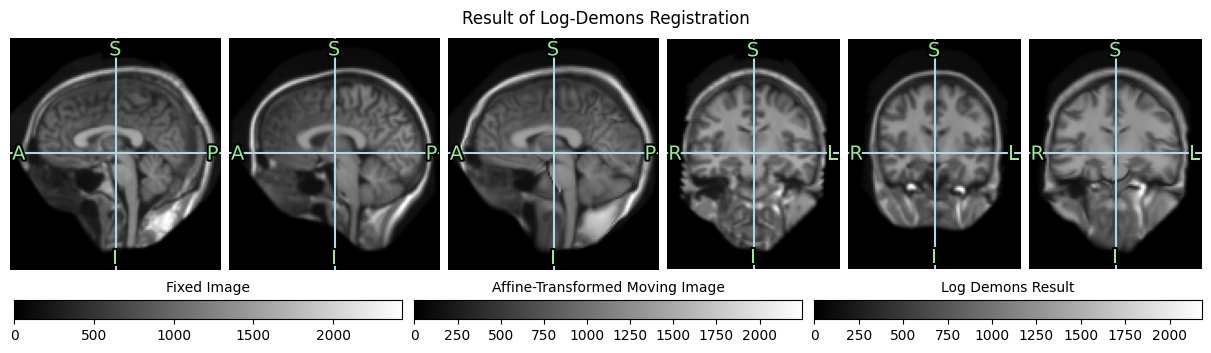

In [ ]:
# Apply the final transformation to the moving image (we avoid double interpolation by applying both warp and affine transform to the moving image)
T_res_warped_logdem = my_transform_image_pytorch(T_grid, T_mov, T_A, T_b, w_i)

# Generate a comparison view
view_sitk(my_torch_to_sitk(T_fix, img_fix),
          my_torch_to_sitk(T_res_aff, img_fix),
          my_torch_to_sitk(T_res_warped_logdem, img_fix),
          layout='ttt', width=12, name=['Fixed Image','Affine-Transformed Moving Image','Log Demons Result'], title='Result of Log-Demons Registration');

### Multi-Resolution Log Demons
A major difference between the registration method above and tools like ANTS is that the latter use multi-resolution schemes for significantly faster optimization. For example, when registering images of 256x256x256 voxels, one would typically subsample to 64x64x64 and run registration at that resolution; then use the result to initialize registration at 128x128x128 resolution, and run that for some number of iterations and use the result to initialize full-resolution registration. This has a dramatic effect on registration quality. This section provides code for multi-resolution Log Demons registration. There is no code for you to write in this section.

First, we coded a function to downsample an image represented as a PyTorch tensor (`my_image_downsample` in `be537_hw2`).

In [ ]:
def my_image_downsample(img, factor):
    """
    Downsample a 3D image with antialiasing

    :param img: Input image represented as a PyTorch [1,C,D,H,W] tensor
    :param factor: Downsampling factor
    :returns: Output image represented as a PyTorch [1,C,D,H,W] tensor
    """

    # Apply smoothing to the image
    img_sm = my_pytorch_gaussian_lpf(img, 0.5 * factor)

    # Determine the output size
    sz_in  = np.array(img_sm.shape[2:5])
    sz_out = np.ceil(sz_in / factor).astype(int)

    # Perform interpolation
    return F.interpolate(img_sm, tuple(sz_out))


This function runs the log-Demons algorithm in a multi-resolution setting

In [ ]:
def my_log_demons_multires(I_fix, I_mov, iter_vec,
                           sigma=2.0, tau=0.5, eps_prime=0.5,
                           of_method='grad_msd', of_param = {}):
    """
    Multi-resolution log Demons algorithm

    :param I_fix: Fixed image, represented as an [N,1,D,H,W] tensor
    :param I_mov: Moving image, represented as an [N,1,D,H,W] tensor
    :param iter_vec:
        Number of iterations at each resolution level, e.g., [100,40] will
        do 100 iterations at 2x downsampling, 40 at full resolution
    :param sigma: See MyOpticalFlow
    :param tau: See MyLogDemonsAlgorithm
    :param eps_prime: See MyLogDemonsAlgorithm
    :param of_method: See MyOpticalFlow
    :param of_param: See MyOpticalFlow

    :returns:
        Tuple (I_res, rms, w, u) where

        - `I_res` is the moving image transformed by the spatial transformation $\\phi$
        - `rms` is the root mean square intensity difference between I and I_res
        - `w` is the displacement field corresponding to $\\phi$
        - `u` is the stationary velocity field corresponding to $\\phi$
    """
    n_levels = len(iter_vec)
    wlast, ulast = None, None
    for level in range(n_levels):
        factor = 2 ** (n_levels - 1 - level)
        #downsample
        if factor > 1:
            I_fix_ds = my_image_downsample(I_fix, factor)
            I_mov_ds = my_image_downsample(I_mov, factor)
        else:
            I_fix_ds = I_fix
            I_mov_ds = I_mov
        #initialize optical flow and demons
        of = MyOpticalFlow(I_fix_ds, method=of_method, sigma=sigma, **of_param)
        log_demons = MyLogDemonsAlgorithm(I_fix_ds, I_mov_ds, of, tau=tau, eps_prime=eps_prime)
        #initialize or upsample w and u
        if wlast is None:
            w_i = torch.zeros_like(I_fix_ds).repeat((1, 3, 1, 1, 1)).permute(0, 2, 3, 4, 1)
            u_i = w_i.clone()
        else:
            wlast_ch = wlast.permute(0, 4, 1, 2, 3)
            ulast_ch = ulast.permute(0, 4, 1, 2, 3)
            w_i_ch = F.interpolate(
                wlast_ch, size=I_fix_ds.shape[2:5],
                mode='trilinear', align_corners=False
            )
            u_i_ch = F.interpolate(
                ulast_ch, size=I_fix_ds.shape[2:5],
                mode='trilinear', align_corners=False
            )
            w_i = w_i_ch.permute(0, 2, 3, 4, 1)
            u_i = u_i_ch.permute(0, 2, 3, 4, 1)
        print(f"resolution lv {level+1}/{n_levels}, factor {factor}, itr {iter_vec[level]}")
        #iterations
        for k in range(iter_vec[level]):
            I_res, msd, w_i, u_i = log_demons.step(w_i, u_i)

            if k % 20 == 0 or k == iter_vec[level] - 1:
                print(f"itr {k:03d}, MSD={msd:8.4f}")
        #store for next level
        wlast = w_i
        ulast = u_i

    return I_res, msd, w_i, u_i


Run a multi-resolution registration. This registration should run faster than the one above and get the final RMS that is under $13,000$.

In [ ]:
_, rms, T_warp_logdem_multires, _ = my_log_demons_multires(T_fix, T_res_aff, [81, 81, 41], of_method='grad_msd') # [81,81,41]

resolution lv 1/3, factor 4, itr 81
itr 000, MSD=38671.8047
itr 020, MSD=16799.5801
itr 040, MSD=16097.6895
itr 060, MSD=16404.5781
itr 080, MSD=16424.2090
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=33391.3125
itr 020, MSD=12666.2744
itr 040, MSD=11777.1621
itr 060, MSD=11090.7139
itr 080, MSD=10543.8896
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=21853.4570
itr 020, MSD=15371.6436
itr 040, MSD=13630.9111


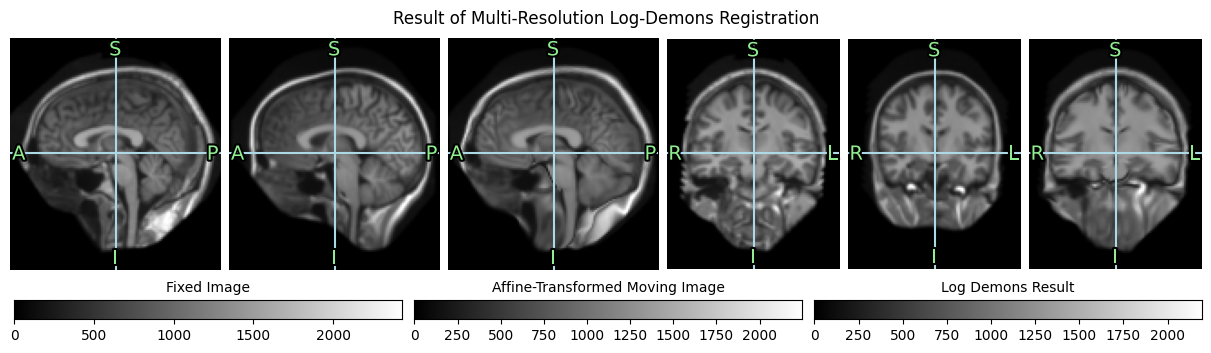

In [ ]:
T_res_warped_logdem_multires = my_transform_image_pytorch(T_grid, T_mov, T_A, T_b, T_warp_logdem_multires)

# Generate a comparison view
view_sitk(my_torch_to_sitk(T_fix, img_fix),
          my_torch_to_sitk(T_res_aff, img_fix),
          my_torch_to_sitk(T_res_warped_logdem_multires, img_fix),
          layout='ttt', width=12, name=['Fixed Image','Affine-Transformed Moving Image','Log Demons Result'], title='Result of Multi-Resolution Log-Demons Registration');

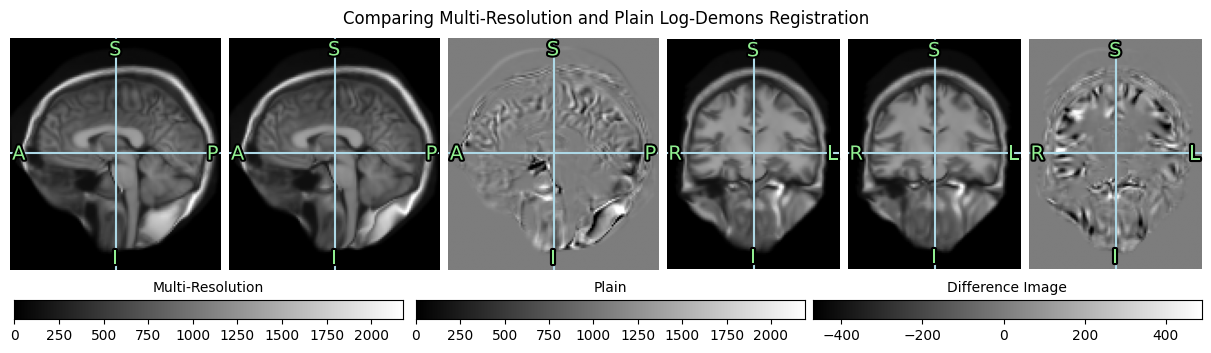

In [ ]:
# Generate a comparison view
view_sitk(my_torch_to_sitk(T_res_warped_logdem, img_fix),
          my_torch_to_sitk(T_res_warped_logdem_multires, img_fix),
          my_torch_to_sitk(T_res_warped_logdem_multires-T_res_warped_logdem, img_fix),
          layout='ttt', width=12, name=['Multi-Resolution','Plain','Difference Image'], title='Comparing Multi-Resolution and Plain Log-Demons Registration');

## Compare Affine and Deformable Registration for 10 Subject Pairs
We will perform deformable registration between 10 randomly selected pairs of subjects in the dataset and evaluate how well these registrations align anatomical labels between images compared to affine registration. To make things simpler, we computed the affine transformations between all image pairs ahead of time.


The class `RegistrationExperiment` below easily load and access all the data associated with each registration experiment. This class provides access to the following variables:

- `exp.T_fix`: Fixed image, represented as a PyTorch tensor
- `exp.T_seg_fix`: Fixed image segmentation, represented as a PyTorch tensor
- `exp.T_mov`: Moving image, represented as a PyTorch tensor
- `exp.T_seg_mov`: Moving image segmentation, represented as a PyTorch tensor
- `exp.T_grid`: Fixed image coordinate grid (for calling `grid_sample`)
- `exp.T_A`, `exp.T_b`: Pytorch affine coordinate transform corresponding to the optimal affine transform computed with Greedy
- `exp.T_A_id`, `exp.T_b_id`: Pytorch affine coordinate transform corresponding to identity transform in image physical space
- `exp.T_mov_aff`: Moving image, affine transformed
- `exp.T_seg_mov_aff`: Moving image segmentation, affine transformed
- `exp.T_mov_id`: Moving image, resliced into fixed image space using identity transform
- `exp.T_seg_mov_id`: Moving image segmentation, resliced into fixed image space using identity transform

In [ ]:
class RegistrationExperiment:

    def find_file(self, pattern, sid):
        fn_a = os.path.join(self.data_path,pattern % ('atlas',sid))
        fn_t = os.path.join(self.data_path,pattern % ('target',sid))
        return fn_a if os.path.exists(fn_a) else fn_t

    def read_image(self, filename, **kwargs):
        img = sitk.ReadImage(filename)
        return my_sitk_to_torch(img, dtype=kwargs.get('dtype',torch.float32), device=kwargs.get('device', 'cpu')), img

    def __init__(self, fixed_id, moving_id, data_path, **kwargs):
        """Initialize the experiment using 4-digit fixed and moving image ids"""
        self.fixed_id = fixed_id
        self.moving_id = moving_id
        self.data_path = data_path

        # Load fixed image
        self.T_fix, self.img_fix = self.read_image(
            self.find_file('images/%s_2mm_%s_3.nii.gz', self.fixed_id), **kwargs)

        # Load moving image
        self.T_mov, self.img_mov = self.read_image(
            self.find_file('images/%s_2mm_%s_3.nii.gz', self.moving_id), **kwargs)

        # Load fixed segmenation
        self.T_seg_fix, self.seg_fix = self.read_image(
            self.find_file('images/%sseg_2mm_%s_3.nii.gz', self.fixed_id), **kwargs)

        # Load moving segmentation
        self.T_seg_mov, self.seg_mov = self.read_image(
            self.find_file('images/%sseg_2mm_%s_3.nii.gz', self.moving_id), **kwargs)

        # Load the affine transform into an sitk object (replace the filename with yours)
        self.tran_itk = load_itksnap_transform(f'{data_path}/affine/affine_fx_{self.fixed_id}_mv_{self.moving_id}.mat')
        A, b = map_affine_sitk_to_pytorch(self.tran_itk, self.img_fix, self.img_mov)
        self.T_A, self.T_b = (torch.tensor(x, dtype=kwargs.get('dtype',torch.float32), device=kwargs.get('device', 'cpu')) for x in (A,b))

        # Because the images have different headers, the identity transformation in Greedy/ANTs
        # space is not the identity in PyTorch space. We need to compute the correct transformation
        # matrix for the identity transform
        id_tran = sitk.AffineTransform(3)
        A_id, b_id = map_affine_sitk_to_pytorch(id_tran, self.img_fix, self.img_mov)
        self.T_A_id, self.T_b_id = (torch.tensor(x, dtype=kwargs.get('dtype',torch.float32), device=kwargs.get('device', 'cpu')) for x in (A_id,b_id))

        # Generate grid
        self.T_grid = my_create_pytorch_grid(self.T_fix.shape, **kwargs)

        # Apply the affine transform to the moving image
        self.T_mov_aff = my_transform_image_pytorch(self.T_grid, self.T_mov, self.T_A, self.T_b)
        self.T_seg_mov_aff = my_transform_image_pytorch(self.T_grid, self.T_seg_mov, self.T_A, self.T_b, mode='nearest')

        # Also apply the identity transform for comparison
        self.T_mov_id = my_transform_image_pytorch(self.T_grid, self.T_mov, self.T_A_id, self.T_b_id)
        self.T_seg_mov_id = my_transform_image_pytorch(self.T_grid, self.T_seg_mov, self.T_A_id, self.T_b_id, mode='nearest')


Here we use the `RegistrationExperiment` class to load a registration experiment between a pair of images

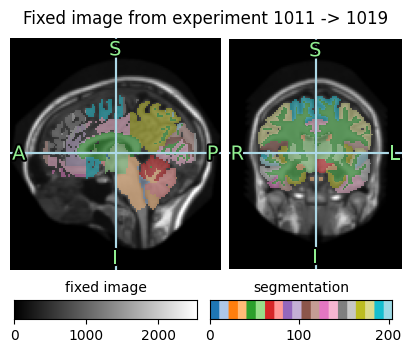

In [ ]:
exp = RegistrationExperiment('1011','1019', root, dtype=torch.float32, device=cuda)

view_sitk(exp.img_fix, exp.seg_fix, layout='to', name=['fixed image','segmentation'], width=4, cmap=['gray','tab20'], alpha=0.5,
          title=f'Fixed image from experiment {exp.fixed_id} -> {exp.moving_id}');


We can now run the log-demons algorithm on this experiment. As before the inputs are the fixed image and the affine-transformed moving image.

In [ ]:
_, rms, w_opt, _ = my_log_demons_multires(exp.T_fix, exp.T_mov_aff, [81, 81, 41], of_method='grad_msd', sigma=1.0)

resolution lv 1/3, factor 4, itr 81
itr 000, MSD=26817.3789
itr 020, MSD=19689.4746
itr 040, MSD=17615.4668
itr 060, MSD=17775.9219
itr 080, MSD=17683.8301
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=34423.9844
itr 020, MSD=12312.1191
itr 040, MSD=11127.4482
itr 060, MSD=11249.0254
itr 080, MSD=10885.0996
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=23013.6523
itr 020, MSD=18550.9082
itr 040, MSD=17444.3555


And visualize the results of this registration:

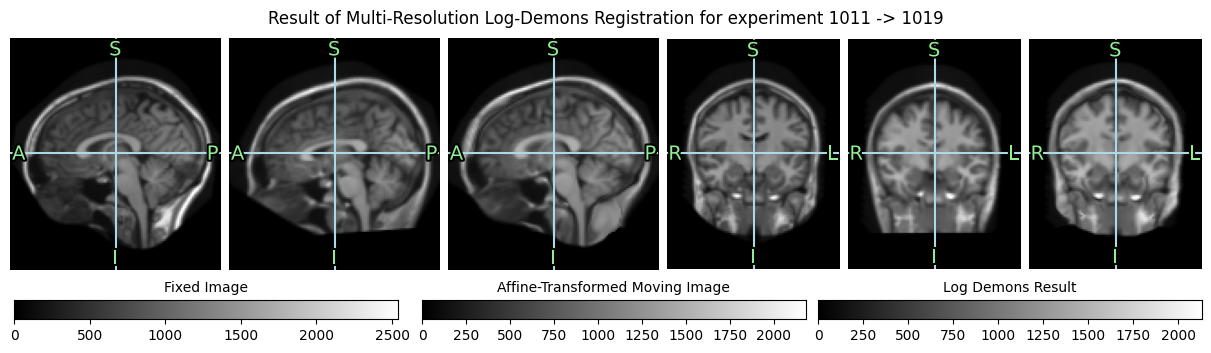

In [ ]:
T_res_warped_logdem_multires = my_transform_image_pytorch(exp.T_grid, exp.T_mov, exp.T_A, exp.T_b, w_opt)

# Generate a comparison view
view_sitk(my_torch_to_sitk(exp.T_fix, exp.img_fix),
          my_torch_to_sitk(exp.T_mov_aff, exp.img_fix),
          my_torch_to_sitk(T_res_warped_logdem_multires, exp.img_fix),
          layout='ttt', width=12, name=['Fixed Image','Affine-Transformed Moving Image','Log Demons Result'],
          title=f'Result of Multi-Resolution Log-Demons Registration for experiment {exp.fixed_id} -> {exp.moving_id}');

### Applying transformations to segmentation images

In [ ]:
def my_generalized_dice(S1, S2, exponent=1):
    """
    Compute Generalized Dice coefficient (Crum et al., IEEE-TMI, 2006) between segmentations

    :param S1: First segmentation image
    :param S2: Second segmentation image
    :param exponent:
        The exponent to which 1/volume is taken when computing the weights of
        individual labels in GDSC computation (see Table 1 in Crum et al.)
    :returns: Generalized Dice coefficient
    """
    d1, d2 = 0, 0
    for k in torch.unique(torch.hstack((S1.flatten(), S2.flatten()))):
        if k > 0:
            s1 = S1 == k
            s2 = S2 == k
            vol = (torch.sum(s1) + torch.sum(s2)) / 2
            w = 1 / vol ** exponent
            d1 += w * torch.sum(s1 * s2)
            d2 += w * vol

    return d1 / d2


### Measuring alignment between segmentations

To measure how well the registration aligned anatomical structures between the fixed and moving images, use the function `my_generalized_dice` to measure the [generalized Dice similarity coefficient](https://ieeexplore.ieee.org/abstract/document/1717643) between the segmentations. GDSC is a measure between 0 and 1 with 0 indicating no overlap and 1 indicating perfect overlap. The code below computes GDSC at different stages of the registration.

Alignment between segmentations images 1011 and 1019
  GDSC before registration:  tensor(0.1033, device='cuda:0')
  GDSC after affine registration tensor(0.2665, device='cuda:0')
  GDSC after deformable registration tensor(0.5309, device='cuda:0')


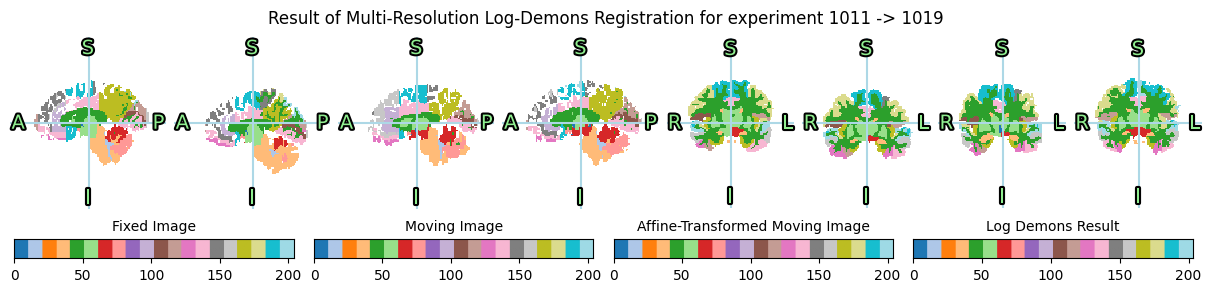

In [ ]:
T_seg_def = my_transform_image_pytorch(exp.T_grid, exp.T_seg_mov, exp.T_A, exp.T_b, w_opt, mode='nearest')

print('Alignment between segmentations images %s and %s' % (exp.fixed_id, exp.moving_id))
print('  GDSC before registration: ', my_generalized_dice(exp.T_seg_fix, exp.T_seg_mov_id))
print('  GDSC after affine registration', my_generalized_dice(exp.T_seg_fix, exp.T_seg_mov_aff))
print('  GDSC after deformable registration', my_generalized_dice(exp.T_seg_fix, T_seg_def))

view_sitk(my_torch_to_sitk(exp.T_seg_fix, exp.img_fix),
          my_torch_to_sitk(exp.T_seg_mov_id, exp.img_fix),
          my_torch_to_sitk(exp.T_seg_mov_aff, exp.img_fix),
          my_torch_to_sitk(T_seg_def, exp.img_fix),
          layout='tttt', width=12, name=['Fixed Image','Moving Image','Affine-Transformed Moving Image','Log Demons Result'],
          title=f'Result of Multi-Resolution Log-Demons Registration for experiment {exp.fixed_id} -> {exp.moving_id}',
          cmap='tab20');

### Jacobian Determinant Computation

In [ ]:
def my_jacobian_determinant_image(T_grid, T_warp):
    """
    Compute the Jacobian determinant image of a 3D transformation represented as a PyTorch tensor

    :param T_grid: Sampling grid, represented as a [1,D,H,W,3] tensor
    :param T_warp: Displacement field w, represented as a [1,D,H,W,3] tensor.
    :returns: Jacobian determinant image of the deformation field $\\phi = Id + w$, represented as a [1,1,D,H,W] tensor
    """
    T_grid = T_grid.to(T_warp.device)
    phi = T_grid + T_warp
    _, D, H, W, _ = phi.shape
    dz = 2.0 / (D - 1)
    dy = 2.0 / (H - 1)
    dx = 2.0 / (W - 1)
    # grads[a] = (dφ_a/dz, dφ_a/dy, dφ_a/dx)
    grads = [torch.gradient(phi[..., i], spacing=(dz, dy, dx), dim=(1, 2, 3))
             for i in range(3)]
    # Correct axis ordering:
    # J[..., 0] = dφ/dx = grads[*][2]
    # J[..., 1] = dφ/dy = grads[*][1]
    # J[..., 2] = dφ/dz = grads[*][0]
    J = torch.stack([
        torch.stack([grads[a][2], grads[a][1], grads[a][0]], dim=-1)
        for a in range(3)
    ], dim=-2)
    detJ = torch.det(J)
    return detJ.unsqueeze(1)

Compute and plot the Jacobian determinant

Jacobian determinant statistics:
  Minimum:  0.11005701869726181
  Maximum:  3.578014373779297
  Mean:     0.9305614829063416
  Stddev:   0.27032241225242615
  % of negative values:  0.0


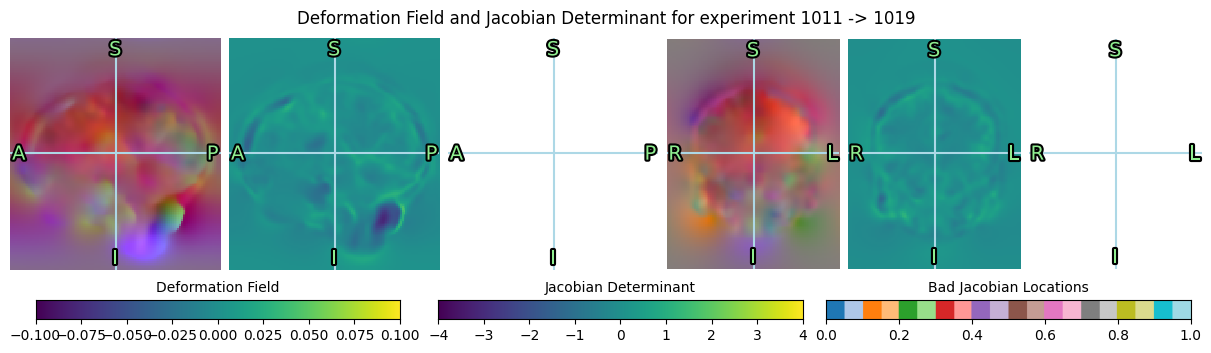

In [ ]:
# Compute the Jacobian determinant image of the final transformation
dJ = my_jacobian_determinant_image(T_grid, w_opt)

# Take the logarithm of the Jacobian determinant for better visualization
log_dJ = torch.where(dJ > 0, torch.log(dJ), torch.tensor(torch.nan, dtype=dJ.dtype, device=dJ.device))

# Report the distribution of Jacobian determinant values inside the segmentation of the fixed image
# (we ignore background voxels, where we don't care as much about diffeomorphism)
mask = exp.T_seg_fix > 0
print('Jacobian determinant statistics:')
print('  Minimum: ', torch.min(dJ[mask]).item())
print('  Maximum: ', torch.max(dJ[mask]).item())
print('  Mean:    ', torch.mean(dJ[mask]).item())
print('  Stddev:  ', torch.std(dJ[mask]).item())
print('  % of negative values: ', torch.sum(dJ[mask] <= 0).item() / dJ[mask].numel() * 100.0)

view_sitk(
    my_torch_to_sitk(w_opt.permute(0,4,1,2,3), exp.img_fix),
    my_torch_to_sitk(log_dJ, exp.img_fix),
    my_torch_to_sitk(torch.where(dJ < 0, 1, 0), exp.img_fix),
    layout='ttt', width=12, name=['Deformation Field','Jacobian Determinant','Bad Jacobian Locations'],
    title=f'Deformation Field and Jacobian Determinant for experiment {exp.fixed_id} -> {exp.moving_id}',
    cmap=['viridis','viridis','tab20'], vmin=[-0.1,-4,0], vmax=[0.1,4,1]);

### Evaluate GDSC for 10 subject pairs


Ten random pairs:

In [ ]:
id_fix_list = [1006, 1000, 1001, 1012, 1013, 1036, 1003, 1011, 1006, 1018]
id_mov_list = [1014, 1007, 1009, 1008, 1010, 1005, 1004, 1015, 1017, 1019]

functions for running grad_msd registration

In [ ]:
def dice(segA, segB):
    A = (segA > 0.5)
    B = (segB > 0.5)
    return (2 * torch.sum(A & B) / (torch.sum(A) + torch.sum(B) + 1e-6)).item()

def run_grad_msd_registration(exp):
    #run LogDemons using grad_msd optical flow
    I_res, rms, w, u = my_log_demons_multires(
        I_fix = exp.T_fix,
        I_mov = exp.T_mov_aff,
        iter_vec = [81,81, 41],
        sigma = 2.0,
        tau = 0.5,
        eps_prime = 0.5,
        of_method = "grad_msd",
        of_param = {}
    )
    #identity affine because your warp requires A and b
    A_id = torch.eye(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    b_id = torch.zeros(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    #warp segmentation using w
    seg_def = my_transform_image_pytorch(
        exp.T_grid,
        exp.T_seg_mov_aff,
        A_id,
        b_id,
        w,
        'nearest'
    )
    #dice score
    d = dice(exp.T_seg_fix, seg_def)

    return d, I_res, seg_def, (w, u)


running grad_msd experiment

In [ ]:
results_gradmsd = []   #store dice + ids
w_gradmsd = []         #store displacement fields
T_grid_saved = None    #save T_grid once

for fix, mov in zip(id_fix_list, id_mov_list):
    print(f"\nRunning {fix}, {mov}")
    exp = RegistrationExperiment(
        str(fix),
        str(mov),
        root,
        dtype=torch.float32,
        device=cuda
    )
    #save T_grid once
    if T_grid_saved is None:
        T_grid_saved = exp.T_grid
    #run grad_msd registration
    dice_val, I_res, seg_res, (w, u) = run_grad_msd_registration(exp)
    print(f"Dice: {dice_val:.4f}")
    #store results
    results_gradmsd.append({
        "fix": fix,
        "mov": mov,
        "dice": float(dice_val)
    })
    #store displacement field for DetJac calculation
    w_gradmsd.append(w)



Running 1006, 1014
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=70877.7891
itr 020, MSD=16240.1699
itr 040, MSD=16812.9570
itr 060, MSD=15673.6719
itr 080, MSD=15812.3359
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=28903.0352
itr 020, MSD=12423.3379
itr 040, MSD=11499.0283
itr 060, MSD=11217.9521
itr 080, MSD=11089.8525
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=23923.5625
itr 020, MSD=18881.1152
itr 040, MSD=17903.1641
Dice: 0.9388

Running 1000, 1007
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=54670.3086
itr 020, MSD=13005.9883
itr 040, MSD=12110.7959
itr 060, MSD=11560.2568
itr 080, MSD=11611.1318
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=25397.5664
itr 020, MSD=10075.1543
itr 040, MSD=8531.6104
itr 060, MSD=8125.4712
itr 080, MSD=8022.2651
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=22118.1270
itr 020, MSD=16164.0225
itr 040, MSD=15145.6309
Dice: 0.9376

Running 1001, 1009
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=46578.0273
itr 020, MSD=1796

functions for Demon registration on 10 pairs

In [ ]:
def run_demons_registration(exp):
    #run LogDemons using Demons optical flow
    I_res, rms, w, u = my_log_demons_multires(
        I_fix = exp.T_fix,
        I_mov = exp.T_mov_aff,
        iter_vec = [81, 81, 41],     #same levels as before
        sigma = 2.0,
        tau = 0.5,
        eps_prime = 0.5,
        of_method = "demons",     #switch OF method here
        of_param = {}             #nothing extra needed
    )
    #identity affine needed for the warp function
    A_id = torch.eye(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    b_id = torch.zeros(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    #warp segmentation through final displacement field w
    seg_def = my_transform_image_pytorch(
        exp.T_grid,
        exp.T_seg_mov_aff,
        A_id,
        b_id,
        w,
        mode='nearest'
    )
    #dice score
    d = dice(exp.T_seg_fix, seg_def)

    return d, I_res, seg_def, (w, u)


Running demon multires experiment

In [ ]:
results_demons = []   #store dice + ids
w_demons = []         #store displacement fields
T_grid_saved = None   #save T_grid once
for fix, mov in zip(id_fix_list, id_mov_list):
    print(f"\nRunning {fix}, {mov}")
    exp = RegistrationExperiment(
        str(fix),
        str(mov),
        root,
        dtype=torch.float32,
        device=cuda
    )
    #save T_grid once
    if T_grid_saved is None:
        T_grid_saved = exp.T_grid
    #run demons registration
    dice_val, I_res, seg_res, (w, u) = run_demons_registration(exp)
    print(f"Dice: {dice_val:.4f}")
    #store results
    results_demons.append({
        "fix": fix,
        "mov": mov,
        "dice": float(dice_val)
    })
    # store displacement field for DetJac calculation
    w_demons.append(w)



Running 1006, 1014
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=70877.7891
itr 020, MSD=144297.0312
itr 040, MSD=247280.0000
itr 060, MSD=293132.1875
itr 080, MSD=321049.2188
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=367577.9062
itr 020, MSD=376040.2188
itr 040, MSD=381170.3438
itr 060, MSD=385345.9062
itr 080, MSD=388601.5625
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=437349.6562
itr 020, MSD=438467.2500
itr 040, MSD=438303.0938
Dice: 0.2023

Running 1000, 1007
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=54670.3086
itr 020, MSD=140364.9844
itr 040, MSD=253175.4062
itr 060, MSD=323785.0625
itr 080, MSD=368944.9375
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=418920.4062
itr 020, MSD=439081.5625
itr 040, MSD=453560.6562
itr 060, MSD=465611.6875
itr 080, MSD=475160.3125
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=521868.6875
itr 020, MSD=522818.0312
itr 040, MSD=523146.3438
Dice: 0.1465

Running 1001, 1009
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=4

Function for running grad_msd with the best parameters found

In [ ]:
def run_grad_msd_registration_tuned(exp, sigma=2.0, tau=0.5, eps_prime=0.5):
    #run LogDemons using grad_msd optical flow
    I_res, rms, w, u = my_log_demons_multires(
        I_fix = exp.T_fix,
        I_mov = exp.T_mov_aff,
        iter_vec = [81,81, 41],  # keep default multi-resolution
        sigma = sigma,
        tau = tau,
        eps_prime = eps_prime,
        of_method = "grad_msd",
        of_param = {}
    )
    #identity affine
    A_id = torch.eye(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    b_id = torch.zeros(3, device=exp.T_fix.device, dtype=exp.T_fix.dtype)
    #warp segmentation
    seg_def = my_transform_image_pytorch(
        exp.T_grid,
        exp.T_seg_mov_aff,
        A_id,
        b_id,
        w,
        'nearest'
    )
    #dice score
    d = dice(exp.T_seg_fix, seg_def)

    return d, I_res, seg_def, (w, u)


searching for the best parameters:

In [ ]:
from itertools import product

sigma_list = [1.5, 2.0, 2.5, 3.0]
tau_list   = [.25, .5, .75]
eps_list   = [.5, .75, 1.0]
best_dice = 0.0
best_params = None
# pick one pair for tuning, e.g., first in your list
fix, mov = id_fix_list[4], id_mov_list[4]
exp = RegistrationExperiment(
    str(fix),
    str(mov),
    root,
    dtype=torch.float32,
    device=cuda
)
for sigma, tau, eps_p in product(sigma_list, tau_list, eps_list):
    print(f"Trying sigma={sigma}, tau={tau}, eps_prime={eps_p} ...")
    d, _, _, _ = run_grad_msd_registration_tuned(exp, sigma=sigma, tau=tau, eps_prime=eps_p)
    print(f"Dice = {d:.4f}")
    if d > best_dice:
        best_dice = d
        best_params = (sigma, tau, eps_p)

print("\nBest Dice:", best_dice)
print("Best parameters: sigma, tau, eps_prime =", best_params)


Trying sigma=1.5, tau=0.25, eps_prime=0.5 ...
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=28047.3672
itr 020, MSD=14011.8018
itr 040, MSD=13039.3818
itr 060, MSD=12299.3955
itr 080, MSD=12920.3477
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=25564.6934
itr 020, MSD=8563.5967
itr 040, MSD=6776.1143
itr 060, MSD=5861.0811
itr 080, MSD=5495.2466
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=15190.9541
itr 020, MSD=9917.9395
itr 040, MSD=9191.4521
Dice = 0.9281
Trying sigma=1.5, tau=0.25, eps_prime=0.75 ...
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=28047.3672
itr 020, MSD=14687.1094
itr 040, MSD=13305.0430
itr 060, MSD=12064.0488
itr 080, MSD=12860.0127
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=27224.6211
itr 020, MSD=9377.3164
itr 040, MSD=7454.5718
itr 060, MSD=6126.9219
itr 080, MSD=6135.5835
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=15283.0117
itr 020, MSD=10415.5000
itr 040, MSD=9364.7871
Dice = 0.9275
Trying sigma=1.5, tau=0.25, eps_prime=1.0 ...
reso

running grad_msd with the best parameters found

In [ ]:
results_gradmsd_tuned = []   #store dice + ids
w_gradmsd_tuned = []         #store displacement fields
T_grid_saved = None          #save T_grid once

for fix, mov in zip(id_fix_list, id_mov_list):
    print(f"\nTuned grad_msd {fix}, {mov}")
    exp = RegistrationExperiment(
        str(fix),
        str(mov),
        root,
        dtype=torch.float32,
        device=cuda
    )
    #save T_grid once
    if T_grid_saved is None:
        T_grid_saved = exp.T_grid
    #input from tuned grad_msd parameter search
    dice_val, I_res, seg_res, (w, u) = run_grad_msd_registration_tuned(
        exp,
        sigma=1.5,
        tau=.5,
        eps_prime=.75
    )
    print(f"Dice: {dice_val:.4f}")
    #store results
    results_gradmsd_tuned.append({
        "fix": fix,
        "mov": mov,
        "dice": float(dice_val)
    })
    #store displacement field for DetJac calculation
    w_gradmsd_tuned.append(w)



Tuned grad_msd 1006, 1014
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=70877.7891
itr 020, MSD=16080.0459
itr 040, MSD=15379.1826
itr 060, MSD=14827.8711
itr 080, MSD=14902.1641
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=27896.6445
itr 020, MSD=11831.3242
itr 040, MSD=10476.5244
itr 060, MSD=10247.8613
itr 080, MSD=10348.4609
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=23425.8945
itr 020, MSD=18138.1211
itr 040, MSD=17038.0059
Dice: 0.9395

Tuned grad_msd 1000, 1007
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=54670.3086
itr 020, MSD=13899.5938
itr 040, MSD=12496.2295
itr 060, MSD=12403.7500
itr 080, MSD=12515.9814
resolution lv 2/3, factor 2, itr 81
itr 000, MSD=27319.8281
itr 020, MSD=9389.6494
itr 040, MSD=7795.0791
itr 060, MSD=7562.0640
itr 080, MSD=7422.2139
resolution lv 3/3, factor 1, itr 41
itr 000, MSD=22262.8418
itr 020, MSD=15556.1748
itr 040, MSD=14279.7158
Dice: 0.9383

Tuned grad_msd 1001, 1009
resolution lv 1/3, factor 4, itr 81
itr 000, MSD=46578.02

Performing no registration and affine only experiments:

In [ ]:
#lists to store results as dictionaries
results_no_reg = []
results_affine = []
#lists to store zero displacement fields for DetJac
w_no_reg = []
w_affine = []
T_grid_saved = None  #save T_grid once
for fix, mov in zip(id_fix_list, id_mov_list):
    exp = RegistrationExperiment(
        str(fix),
        str(mov),
        root,
        dtype=torch.float32,
        device=cuda
    )
    #save T_grid once
    if T_grid_saved is None:
        T_grid_saved = exp.T_grid
    #no registration (identity transform)
    d_no = dice(exp.T_seg_fix, exp.T_seg_mov_id)
    results_no_reg.append({
        "fix": fix,
        "mov": mov,
        "dice": float(d_no)
    })
    #zero displacement field for DetJac
    w_zero = torch.zeros_like(exp.T_grid)
    w_no_reg.append(w_zero)
    # affine only
    d_aff = dice(exp.T_seg_fix, exp.T_seg_mov_aff)
    results_affine.append({
        "fix": fix,
        "mov": mov,
        "dice": float(d_aff)
    })
    #affine-only displacement field is effectively zero
    w_affine.append(w_zero)


Compiling results into a table:

In [ ]:
import pandas as pd

#extract dice values
dice_no_reg = np.array([r['dice'] for r in results_no_reg])
dice_affine = np.array([r['dice'] for r in results_affine])
dice_gradmsd = np.array([r['dice'] for r in results_gradmsd])
dice_demons = np.array([r['dice'] for r in results_demons])
dice_gradmsd_tuned = np.array([r['dice'] for r in results_gradmsd_tuned])
#function to compute mean ± SD
def mean_sd(arr):
    return f"{arr.mean():.3f} ± {arr.std():.3f}"
#function to compute DetJac stats
def detjac_stats(T_grid, w_list):
    #compute mean ± SD and % negative of jacobian determinant for a list of displacement fields
    all_detJ = []
    for w in w_list:
        detJ = my_jacobian_determinant_image(T_grid, w)  # [1,1,D,H,W]
        all_detJ.append(detJ.flatten().cpu().numpy())
    all_detJ = np.concatenate(all_detJ)
    mean_det = all_detJ.mean()
    std_det = all_detJ.std()
    pct_neg = 100 * np.sum(all_detJ < 0) / all_detJ.size
    return f"{mean_det:.3f} ± {std_det:.3f}, {pct_neg:.1f}%"
#build table
table = pd.DataFrame({
    "Method": [
        "No registration",
        "Affine only",
        "Affine + deformable (grad_msd)",
        "Affine + deformable (Demons)",
        "Affine + deformable (best parameters)"
    ],
    "Dice Coefficient (Mean ± SD)": [
        mean_sd(dice_no_reg),
        mean_sd(dice_affine),
        mean_sd(dice_gradmsd),
        mean_sd(dice_demons),
        mean_sd(dice_gradmsd_tuned)
    ],
    "DetJac Stats (Mean ± SD, %negative)": [
        detjac_stats(T_grid_saved, w_no_reg),
        detjac_stats(T_grid_saved, w_affine),
        detjac_stats(T_grid_saved, w_gradmsd),
        detjac_stats(T_grid_saved, w_demons),
        detjac_stats(T_grid_saved, w_gradmsd_tuned)
    ]
})
print(table)


                                  Method Dice Coefficient (Mean ± SD)  \
0                        No registration                0.851 ± 0.036   
1                            Affine only                0.857 ± 0.039   
2         Affine + deformable (grad_msd)                0.929 ± 0.023   
3           Affine + deformable (Demons)                0.206 ± 0.063   
4  Affine + deformable (best parameters)                0.930 ± 0.026   

  DetJac Stats (Mean ± SD, %negative)  
0                 0.973 ± 0.000, 0.0%  
1                 0.973 ± 0.000, 0.0%  
2                 0.973 ± 0.365, 0.0%  
3                 0.950 ± 1.315, 0.0%  
4                 0.973 ± 0.368, 0.0%  


The Dice coefficients demonstrate a measure of overall alignment between the pairs, and the table here displays an average coeffecient across all 10 pairs for each of the experiments. The first row is the baseline, showing that with no registration the images are already reasonably aligned. The second row shows a slightly better score because global alignments were used (affine registration). The third row, gradient based MSD registration, shows great improvement because this method is stable and smooth. The fourth row stands out because of the decrease in score. This could be due to the instability of the demons method. This means that because demons assumed small differences in intensity, when it encounters noise the computed displacement becomes large and unstable. The default parameters (sigma = 2.0, tau = 0.5, eps_prime = 0.5) also offer weak smoothing and large updates. The final row shows a slightly better score than row 3, which makes sense since parameters were selected to improve the dice coefficient.

The Jacobian Determinant tells you if a deformation is an expansion (>1), compression (<1), volume preserving (=1), or were folded/non-vertible (<0). A majority of the DetJac scores were 0.973, showing mostly volume preserving deformations. The standard deviations are also mostly low. The exception here is again the Demons experiment, where the DetJac was .950 +/- 1.315. The relatively large std indicates that there were larger local expansions and compressions compared to the other methods. This makes sense considering the large difference in Dice coefficient as well. The final column showed the % negative, which was 0 for all, indicated that none of the methods caused topological folding.